____
### 1. Imports

In [25]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

____
### 2. Exploring Environment

In [26]:
env = gym.make("Blackjack-v1")

print("Action space:", env.action_space)   # 0 = stick, 1 = hit
state, _ = env.reset()
print("Meaning: (own sum, dealer's card shown, usable ace)")
print("State:", state)
print("\n")



def print_env(next_env, action):
    d = {1: "WIN", -1: "LOSS", 0: "CONT"}
    next_state, reward, terminated, truncated, i = next_env
    print("--NEXT--")
    print(f"Action Chosen: {'Hit' if action else 'Stick'}")
    print(f"Next State: {next_state}")
    print(f"Reward: {reward} ({d[reward]})")
    if terminated:
        print("\n--NEW GAME--")
        state, i = env.reset()
    return reward



Action space: Discrete(2)
Meaning: (own sum, dealer's card shown, usable ace)
State: (18, 10, 0)




In [27]:
# Watch a few random steps
res = 0
for i in range(5): # iterating 5 times
    action = env.action_space.sample() #pick a random action, either sticking or hitting
    next_env = env.step(action) # obtain the new environment after applying the effects of the action on it
    reward = print_env(next_env, action) #print the new environment
    res += reward

print(f"\nCumulative reward = {res}")
env.close()

--NEXT--
Action Chosen: Stick
Next State: (18, 10, 0)
Reward: -1.0 (LOSS)

--NEW GAME--
--NEXT--
Action Chosen: Hit
Next State: (19, 3, 0)
Reward: 0.0 (CONT)
--NEXT--
Action Chosen: Stick
Next State: (19, 3, 0)
Reward: 1.0 (WIN)

--NEW GAME--
--NEXT--
Action Chosen: Stick
Next State: (10, 10, 0)
Reward: -1.0 (LOSS)

--NEW GAME--
--NEXT--
Action Chosen: Hit
Next State: (27, 1, 0)
Reward: -1.0 (LOSS)

--NEW GAME--

Cumulative reward = -2.0


____
### 3. Instantiating the Q-table

In [28]:
# defaultdict automatically creates a new entry when a state is seen for first time
# Each state maps to an array of 2 Q-values [stick, hit]

q_table = defaultdict(lambda: np.zeros(2))

# Test it
print("Q-values for unseen state (18, 6, False):", q_table[(18, 6, False)])

Q-values for unseen state (18, 6, False): [0. 0.]


____
### 4. Hyperparameters

In [29]:
# episodes = number of rounds the simulation will run 
EPISODES = 500_000   # Blackjack needs more episodes — rounds are very short

#alpha = amount to update the q-value each time, the learning rate of the model
ALPHA = 0.01      # lower learning rate — more stable for noisy card games

#gamma = the amount to value future rewards 
GAMMA = 1.0       # no discounting — each round is self contained

#epsilon = exploration rate, eps = 1 means the agent starts at a completely random decision
EPSILON = 1.0

#minimum floor for epsilon kept at 0.01 so that there is a tiny bit of randomness left regardless
EPSILON_MIN = 0.01

#how much epsilon changes after each episode, kept to small amount so that decay is slow
EPSILON_DECAY = 0.999995

____
### 5. Training the model (agent)

In [30]:
def make_decision(eps, q_table, state, env):
    if np.random.random() < eps:
        return env.action_space.sample()
    else:
        return np.argmax(q_table[state])
    
def update_qtable(q_table, state, next_state, action, reward):
    best_nxt_action = np.max(q_table[next_state])
    curr_est = q_table[state][action] # current estimate of the action taken based off value inside qtable
    tgt = reward + GAMMA * best_nxt_action  #the actual value of the action 
    err = tgt - curr_est #error in current estimate

    q_table[state][action] = curr_est + ALPHA * (tgt - curr_est) # updating the value inside the q-table


In [33]:
env = gym.make("Blackjack-v1") ## creating a new environment
rewards_per_episode = []

for episode in range(EPISODES):
    state, i = env.reset()
    total_reward = 0

    while True:
        action = make_decision(EPSILON, q_table, state, env)
        
        next_state, reward, terminated, truncated, i = env.step(action)
        done = terminated or truncated # combining the done boolean flag into one based off terminated or truncated

        update_qtable(q_table, state, next_state, action, reward) #updates the Q table

        state = next_state
        total_reward += reward

        if done: # goes to next episode if done
            break

    EPSILON = max(EPSILON_MIN, EPSILON * EPSILON_DECAY) #changes the epsilon value, shrinking it but making sure it does not become lower than the min that is set
    rewards_per_episode.append(total_reward) #logs the reward of that round 

    if (episode + 1) % 50000 == 0:
        avg = np.mean(rewards_per_episode[-50000:])
        print(f"Episode {episode+1:>7} | Avg Reward: {avg:.4f} | Epsilon: {EPSILON:.4f}")

env.close()
print("\nTraining complete!")

Episode   50000 | Avg Reward: -0.3663 | Epsilon: 0.7788
Episode  100000 | Avg Reward: -0.3213 | Epsilon: 0.6065
Episode  150000 | Avg Reward: -0.2960 | Epsilon: 0.4724
Episode  200000 | Avg Reward: -0.2790 | Epsilon: 0.3679
Episode  250000 | Avg Reward: -0.2643 | Epsilon: 0.2865
Episode  300000 | Avg Reward: -0.2232 | Epsilon: 0.2231
Episode  350000 | Avg Reward: -0.2221 | Epsilon: 0.1738
Episode  400000 | Avg Reward: -0.2050 | Epsilon: 0.1353
Episode  450000 | Avg Reward: -0.2261 | Epsilon: 0.1054
Episode  500000 | Avg Reward: -0.1856 | Epsilon: 0.0821

Training complete!


____
### 6. Plot Learning Curve

In [ ]:
def rolling_avg(data, window=10000):
    return np.convolve(data, np.ones(window)/window, mode='valid')

smoothed = rolling_avg(rewards_per_episode, window=10000)

plt.figure(figsize=(10, 5))
plt.plot(smoothed, color='steelblue', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', label='Break even')
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Blackjack Q-Learning — Agent Learning Curve")
plt.legend()
plt.tight_layout()
plt.show()

____
### 7. Visualise Policy Built

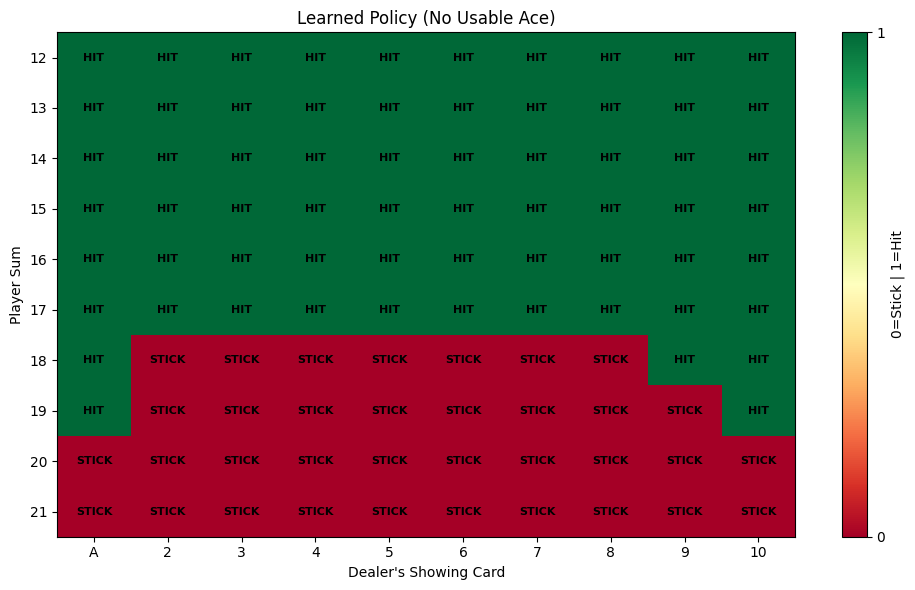

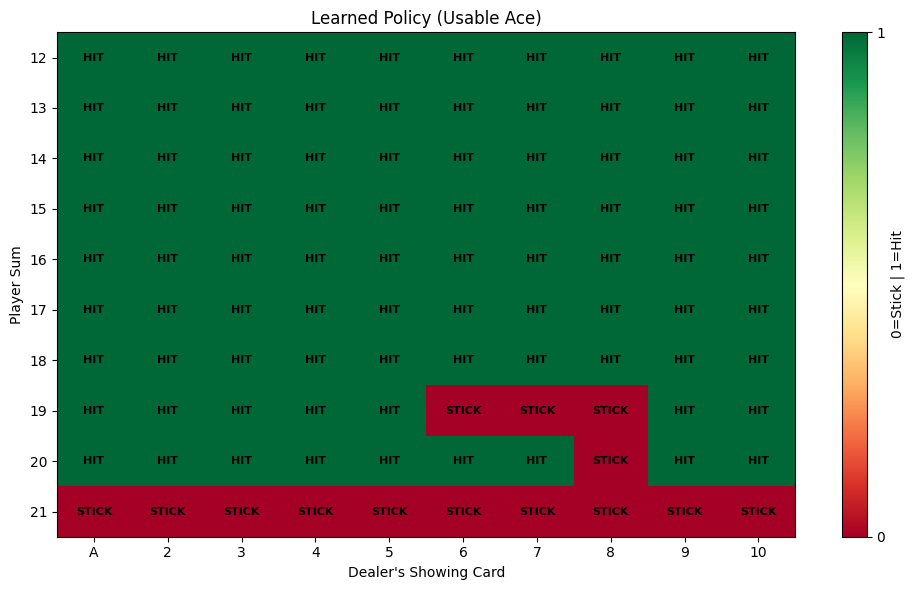

In [ ]:
def plot_policy(q_table, usable_ace=False):
    policy = np.zeros((10, 10))   # player sums 12–21, dealer cards 1–10

    for player_sum in range(12, 22):
        for dealer_card in range(1, 11):
            state = (player_sum, dealer_card, usable_ace)
            action = np.argmax(q_table[state])
            policy[player_sum - 12][dealer_card - 1] = action

    fig, ax = plt.subplots(figsize=(10, 6))
    cmap = plt.cm.RdYlGn
    im = ax.imshow(policy, cmap=cmap, aspect='auto', vmin=0, vmax=1)

    ax.set_xticks(range(10))
    ax.set_xticklabels(['A','2','3','4','5','6','7','8','9','10'])
    ax.set_yticks(range(10))
    ax.set_yticklabels(range(12, 22))
    ax.set_xlabel("Dealer's Showing Card")
    ax.set_ylabel("Player Sum")
    title = "Learned Policy (Usable Ace)" if usable_ace else "Learned Policy (No Usable Ace)"
    ax.set_title(title)

    # Add text labels
    for i in range(10):
        for j in range(10):
            text = "HIT" if policy[i][j] == 1 else "STICK"
            ax.text(j, i, text, ha='center', va='center', fontsize=8, fontweight='bold')

    plt.colorbar(im, ax=ax, ticks=[0, 1], label='0=Stick | 1=Hit')
    plt.tight_layout()
    plt.show()

plot_policy(q_table, usable_ace=False)
plot_policy(q_table, usable_ace=True)

____
### 8. Evaluating Agent 

In [34]:
def evaluate_agent(num_games):
    wins, losses, draws = 0, 0, 0
    for _ in range(num_games):
        state, _ = env.reset()
        while True:
            action = np.argmax(q_table[state])    # pure exploitation, no randomness
            state, reward, terminated, truncated, _ = env.step(action)
            if terminated or truncated:
                if reward > 0:   
                    wins += 1
                elif reward < 0: 
                    losses += 1
                else:            
                    draws += 1
                break
    env.close()
    total = wins + losses + draws
    print(f"Results over {num_games:,} games:")
    print(f"Wins:   {wins:>6,}  ({wins/total*100:.1f}%)")
    print(f"Losses: {losses:>6,}  ({losses/total*100:.1f}%)")
    print(f"Draws:  {draws:>6,}  ({draws/total*100:.1f}%)")




In [36]:
number_sim = 100000
evaluate_agent(number_sim)



Results over 100,000 games:
Wins:   38,833  (38.8%)
Losses: 52,968  (53.0%)
Draws:   8,199  (8.2%)


____
### 9. Tuning Agent for improved performance

#### 9.1 Tuning HyperParameters

In [ ]:
# episodes = number of rounds the simulation will run 
#EPISODES = 500_000 

#alpha = amount to update the q-value each time, the learning rate of the model
# ALPHA = 0.01  

#gamma = the amount to value future rewards 
# GAMMA = 1.0       # no discounting — each round is self contained

#epsilon = exploration rate, eps = 1 means the agent starts at a completely random decision
# EPSILON = 1.0

#minimum floor for epsilon kept at 0.01 so that there is a tiny bit of randomness left regardless
# EPSILON_MIN = 0.01

#how much epsilon changes after each episode, kept to small amount so that decay is slow
# EPSILON_DECAY = 0.999995

#### 9.2 Instantiating Q-table

In [37]:
def create_qtable():
    return defaultdict(lambda: np.ones(2) * 0.5)

q_table_a = create_qtable()
q_table_b = create_qtable()
visit_counts = defaultdict(int) # keeping track of how many times each state is visited


#### 9.3 Functions that utilise 2 Q-tables instead of just 1

In [38]:

def make_decision(eps, q_table_a, q_table_b, state, env):
    visit_counts[state] += 1
    state_eps = max(EPSILON_MIN, 1.0 / np.sqrt(visit_counts[state])) #use 1/sqrt(visit_counts) so that epsilon does not decay aggressively
    if np.random.random() < state_eps:
        return env.action_space.sample()
    else:
        combined = q_table_a[state] + q_table_b[state] # use avg of both tables to decide
        return np.argmax(combined)
    

def update_qtable(q_table_a, q_table_b, state, next_state, action, reward):
    if np.random.random() < 0.5: # randomly chooses which table is evaluated
        # table A updated, table B used to evaluate
        best_action = np.argmax(q_table_a[next_state]) #table A decision obtained
        tgt = reward + GAMMA * q_table_b[next_state][best_action] #evaluated against table B
        q_table_a[state][action] += ALPHA * (tgt - q_table_a[state][action])
    else: # table B updated, table A used to evaluate
        best_action = np.argmax(q_table_b[next_state]) # table B decision obtained
        tgt = reward + GAMMA * q_table_a[next_state][best_action] #evaluated against table A
        q_table_b[state][action] += ALPHA * (tgt - q_table_b[state][action]) #updating table B

#### 9.4 Training Model with new approach

In [39]:
for episode in range(EPISODES):
    state, _ = env.reset()
    total_reward = 0
    while True:
        action = make_decision(EPSILON, q_table_a, q_table_b, state, env)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        update_qtable(q_table_a, q_table_b, state, next_state, action, reward)

        state = next_state
        total_reward += reward

        if done:
            break

    rewards_per_episode.append(total_reward)

    if (episode + 1) % 50000 == 0:
        avg = np.mean(rewards_per_episode[-50000:])
        print(f"Episode {episode+1:>7} | Avg Reward: {avg:.4f}")

env.close()
print("\nTraining complete!")

Episode   50000 | Avg Reward: -0.1398
Episode  100000 | Avg Reward: -0.1665
Episode  150000 | Avg Reward: -0.1812
Episode  200000 | Avg Reward: -0.1770
Episode  250000 | Avg Reward: -0.1754
Episode  300000 | Avg Reward: -0.1775
Episode  350000 | Avg Reward: -0.1830
Episode  400000 | Avg Reward: -0.1803
Episode  450000 | Avg Reward: -0.1736
Episode  500000 | Avg Reward: -0.1792

Training complete!


#### 9.5 Re-evaluate model

In [40]:
def evaluate_agent(q_table_a, q_table_b, episodes=100_000):
    env = gym.make("Blackjack-v1")
    wins, losses, draws = 0, 0, 0
    for _ in range(episodes):
        state, _ = env.reset()
        while True:
            combined = q_table_a[state] + q_table_b[state]
            action = np.argmax(combined) # pure exploitation
            state, reward, terminated, truncated, _ = env.step(action)
            if terminated or truncated:
                if reward > 0:    wins += 1
                elif reward < 0:  losses += 1
                else:             draws += 1
                break
    env.close()
    total = wins + losses + draws
    print(f"Results over {episodes:,} games:")
    print(f"  Wins:   {wins:>6,}  ({wins/total*100:.1f}%)")
    print(f"  Losses: {losses:>6,}  ({losses/total*100:.1f}%)")
    print(f"  Draws:  {draws:>6,}  ({draws/total*100:.1f}%)")
    return wins / total

win_rate = evaluate_agent(q_table_a, q_table_b)

Results over 100,000 games:
  Wins:   37,463  (37.5%)
  Losses: 54,583  (54.6%)
  Draws:   7,954  (8.0%)
